# Structural Analysis of the ENZYMES Dataset

This notebook performs a structural analysis of the ENZYMES dataset similar to the one conducted for the Cora citation network.  

Since ENZYMES contains multiple small graphs rather than a single large graph, structural statistics are computed per graph and then aggregated across the dataset.

We analyze:

- Edge betweenness centrality distribution
- Highest betweenness edges
- Growth of k-hop neighborhoods
- Graph size statistics

These diagnostics help identify potential structural bottlenecks that may affect message passing in Graph Neural Networks.

In [6]:
import sys
import os
import time
import random
import json

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from torch_geometric.datasets import Planetoid, TUDataset
from torch_geometric.utils import to_networkx
from torch_geometric.transforms import NormalizeFeatures

import networkx as nx

In [8]:
sns.set_style("white")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.grid": False
})

os.makedirs("figures", exist_ok=True)

## Dataset

The experiments are conducted on the Enzymes dataset

In [9]:
dataset = TUDataset(root="../data", name="ENZYMES")

print(dataset)
print("Number of graphs:", len(dataset))
print("Num node features:", dataset.num_features)
print("Num classes:", dataset.num_classes)

ENZYMES(600)
Number of graphs: 600
Num node features: 3
Num classes: 6


In [8]:
num_nodes = []
num_edges = []

for data in dataset:
    num_nodes.append(data.num_nodes)
    num_edges.append(data.num_edges)

print("Average nodes per graph:", np.mean(num_nodes))
print("Average edges per graph:", np.mean(num_edges))

Average nodes per graph: 32.63333333333333
Average edges per graph: 124.27333333333333


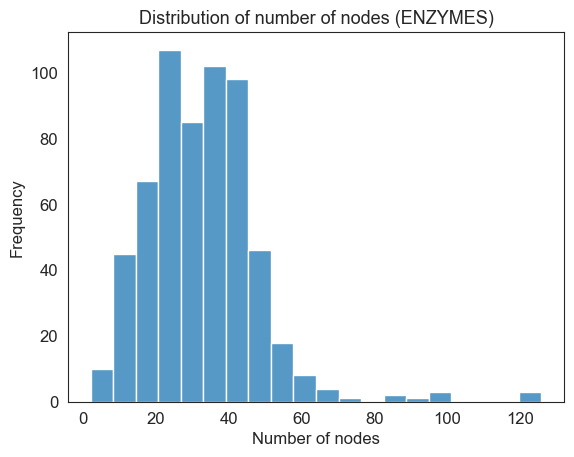

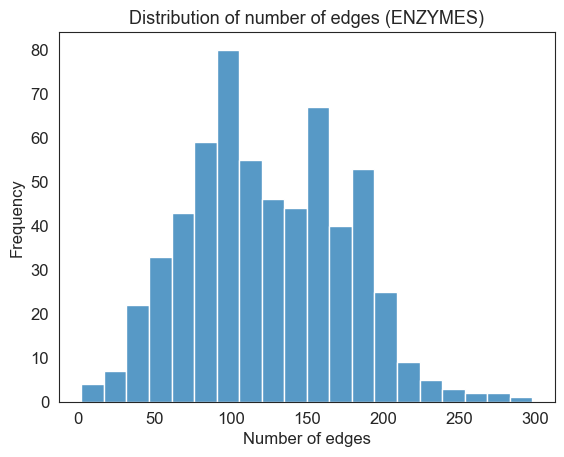

In [24]:
num_nodes = []
num_edges = []

for data in dataset:
    num_nodes.append(data.num_nodes)
    num_edges.append(data.num_edges)

plt.figure()
sns.histplot(num_nodes, bins=20, kde=False)
plt.title("Distribution of number of nodes (ENZYMES)")
plt.xlabel("Number of nodes")
plt.ylabel("Frequency")
plt.savefig(
    "../results/plots/enzymes/distribution_nodes.png",
    dpi=300
)
plt.show()

plt.figure()
sns.histplot(num_edges, bins=20, kde=False)
plt.title("Distribution of number of edges (ENZYMES)")
plt.xlabel("Number of edges")
plt.ylabel("Frequency")
plt.savefig(
    "../results/plots/enzymes/distribution of edges.png",
    dpi=300
)
plt.show()

In [11]:
nx_graphs = []

for data in dataset:
    G = to_networkx(data, to_undirected=True)
    nx_graphs.append(G)

print("Converted graphs:", len(nx_graphs))

Converted graphs: 600


In [15]:
betweenness_values = []

for G in nx_graphs:
    if G.number_of_edges() == 0:
        continue
        
    edge_bet = nx.edge_betweenness_centrality(G)
    betweenness_values.extend(edge_bet.values())

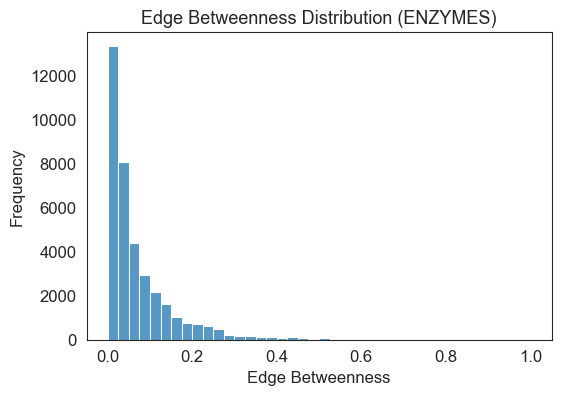

In [25]:
plt.figure(figsize=(6,4))

sns.histplot(betweenness_values, bins=40)

plt.xlabel("Edge Betweenness")
plt.ylabel("Frequency")
plt.title("Edge Betweenness Distribution (ENZYMES)")
plt.savefig(
    "../results/plots/enzymes/edge_betweenness.png",
    dpi=300
)

plt.show()

In [18]:
top_values = sorted(betweenness_values)[-50:]
top_values = np.sort(top_values)

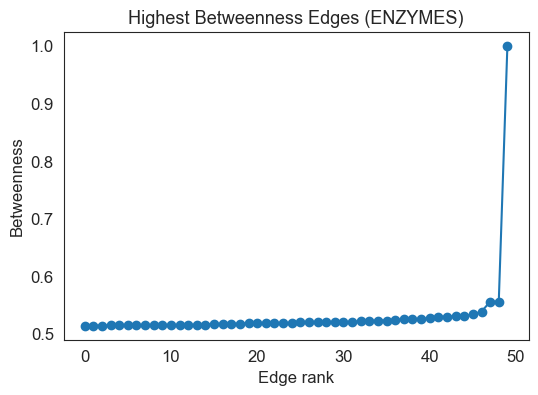

In [29]:
plt.figure(figsize=(6,4))

plt.plot(top_values, marker='o')

plt.xlabel("Edge rank")
plt.ylabel("Betweenness")
plt.title("Highest Betweenness Edges (ENZYMES)")
plt.savefig(
    "../results/plots/enzymes/highest_betweenness_edges_enzymes.png",
    dpi=300
)
plt.show()

In [30]:
def average_khop_growth(graphs, max_k=5):

    growth = []

    for k in range(1, max_k+1):

        sizes = []

        for G in graphs:

            if len(G.nodes()) == 0:
                continue

            node = list(G.nodes())[0]

            nodes = nx.single_source_shortest_path_length(G, node, cutoff=k)

            sizes.append(len(nodes))

        growth.append(np.mean(sizes))

    return growth

In [31]:
khop_growth = average_khop_growth(nx_graphs)

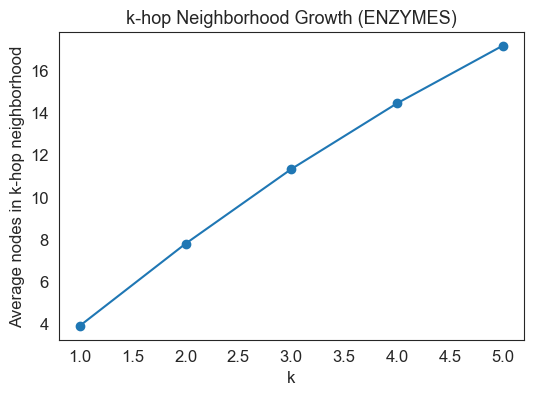

In [32]:
plt.figure(figsize=(6,4))

plt.plot(range(1,6), khop_growth, marker='o')

plt.xlabel("k")
plt.ylabel("Average nodes in k-hop neighborhood")
plt.title("k-hop Neighborhood Growth (ENZYMES)")
plt.savefig(
    "../results/plots/enzymes/average_nodes_in_khop.png",
    dpi=300
)
plt.show()

## Baseline GNN Performance on ENZYMES

In this section we evaluate how model depth affects performance and computational cost
on the ENZYMES dataset.

We train baseline GNN architectures with different numbers of layers and measure:

- test accuracy
- training time

These experiments help identify whether increasing depth introduces optimization
difficulties or structural limitations related to message passing.

In [3]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.models.gcn import GCN
from src.models.graphsage import GraphSAGE
from src.models.gat import GAT

from src.training.train import train_enzymes
from src.training.evaluate import evaluate_enzymes

c:\Master\GAI\gnn-over-squashing-cora\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = {
    "gcn": GCN,
    "graphsage": GraphSAGE,
    "gat": GAT
}

in_dim = dataset.num_features
num_classes = dataset.num_classes

hidden_dim = 64
epochs = 200
lr = 0.005
weight_decay = 0.0005

layer_values = [2, 3, 4, 6, 8]

results = {m: {"layers": [], "acc": [], "time": []} for m in models.keys()}

train_dataset, test_dataset = train_test_split(dataset, test_size=0.2, random_state=42)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


for model_name, Model in models.items():

    print(f"\nRunning experiments for {model_name.upper()}")

    for layers in layer_values:

        model = Model(in_dim, hidden_dim, num_classes, layers).to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

        start = time.time()

        history = train_enzymes(
            model,
            train_loader,
            optimizer,
            epochs=epochs,
            device=device
        )

        elapsed = time.time() - start

        acc = evaluate_enzymes(
            model,
            test_loader,
            device=device
        )

        results[model_name]["layers"].append(layers)
        results[model_name]["acc"].append(acc)
        results[model_name]["time"].append(elapsed)

        print(
            f"{model_name} | layers={layers} | acc={acc:.3f} | time={elapsed:.1f}s"
        )


Running experiments for GCN


  0%|          | 0/200 [00:00<?, ?it/s]


TypeError: GCN.forward() takes 3 positional arguments but 4 were given